## Phase 1 — Dataset Loading

In [325]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [326]:
# Load Career_RIASEC_df
Career_RIASEC_df = pd.read_csv('career_data_extended.csv')

# Load Career_Education_df
Career_Education_df = pd.read_excel('career_dataset_large.xlsx')

In [327]:
print('First rows of Career_RIASEC_df:')
display(Career_RIASEC_df.head())

print('\nFirst rows of Career_Education_df:')
display(Career_Education_df.head())

First rows of Career_RIASEC_df:


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career
0,88,90,3,4,2,5,3,5,3,9,2,Entrepreneur
1,87,67,3,3,5,2,1,1,4,4,8,Accountant
2,65,70,4,4,2,2,3,4,7,4,1,Teacher
3,94,74,2,2,4,1,1,1,1,1,7,Accountant
4,88,71,2,4,4,7,2,3,0,6,2,Entrepreneur



First rows of Career_Education_df:


,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,Bachelor's,Finance,"Counseling, MS Office, Machine Learning",Tally ERP,67,Business Analyst
1,Intermediate,Science,"Accounting, MS Office",AWS Certified,67,Software Engineer
2,Master's,Business,"Accounting, SQL, Data Analysis",Mental Health Basics,90,Financial Analyst
3,Bachelor's,Computer Science,Communication,NaN,75,Clerk
4,Matric,Business,Data Analysis,Tally ERP,83,Sales Assistant


## Phase 2 — Dataset Inspection

In [328]:
print(f'RIASEC Dataset Shape: {Career_RIASEC_df.shape}')
print(f'Education Dataset Shape: {Career_Education_df.shape}')

RIASEC Dataset Shape: (5000, 12)
Education Dataset Shape: (5000, 6)


In [329]:
print('RIASEC Columns:', Career_RIASEC_df.columns.tolist())
print('Education Columns:', Career_Education_df.columns.tolist())

RIASEC Columns: ['Math_Score', 'Science_Score', 'Programming_Skill', 'Communication_Skill', 'Logical_Ability', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score', 'Career']
Education Columns: ['Education Level', 'Specialization', 'Skills', 'Certifications', 'CGPA/Percentage', 'Recommended Career']


In [330]:
print('--- RIASEC Info ---')
Career_RIASEC_df.info()
print('\n--- Education Info ---')
Career_Education_df.info()

--- RIASEC Info ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Math_Score           5000 non-null   int64
 1   Science_Score        5000 non-null   int64
 2   Programming_Skill    5000 non-null   int64
 3   Communication_Skill  5000 non-null   int64
 4   Logical_Ability      5000 non-null   int64
 5   R_score              5000 non-null   int64
 6   I_score              5000 non-null   int64
 7   A_score              5000 non-null   int64
 8   S_score              5000 non-null   int64
 9   E_score              5000 non-null   int64
 10  C_score              5000 non-null   int64
 11  Career               5000 non-null   str  
dtypes: int64(11), str(1)
memory usage: 522.4 KB

--- Education Info ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dty

In [331]:
print('--- RIASEC Summary Statistics ---')
display(Career_RIASEC_df.describe())
print('\n--- Education Summary Statistics ---')
display(Career_Education_df.describe())

--- RIASEC Summary Statistics ---


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,79.632600,79.114800,3.222200,3.517200,3.729200,2.992600,5.021400,3.173800,4.190800,3.387000,4.741400
std,9.556751,10.199001,0.956352,1.015633,1.037151,1.880333,2.863666,1.897765,2.724533,2.461472,2.651855
min,60.000000,60.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,71.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,81.000000,81.000000,3.000000,4.000000,4.000000,3.000000,5.000000,3.000000,4.000000,3.000000,5.000000
75%,87.000000,88.000000,4.000000,4.000000,5.000000,4.000000,8.000000,4.000000,7.000000,4.000000,7.000000
max,97.000000,97.000000,5.000000,5.000000,5.000000,8.000000,10.000000,8.000000,10.000000,10.000000,10.000000



--- Education Summary Statistics ---


,CGPA/Percentage
count,5000.000000
mean,77.479800
std,10.396288
min,60.000000
25%,68.000000
50%,77.000000
75%,87.000000
max,95.000000


In [332]:
print('--- RIASEC Null Values ---')
print(Career_RIASEC_df.isnull().sum())
print('\n--- Education Null Values ---')
print(Career_Education_df.isnull().sum())

--- RIASEC Null Values ---
Math_Score             0
Science_Score          0
Programming_Skill      0
Communication_Skill    0
Logical_Ability        0
R_score                0
I_score                0
A_score                0
S_score                0
E_score                0
C_score                0
Career                 0
dtype: int64

--- Education Null Values ---
Education Level         0
Specialization          0
Skills                  0
Certifications        596
CGPA/Percentage         0
Recommended Career      0
dtype: int64


In [333]:
print(f'RIASEC Duplicate Rows: {Career_RIASEC_df.duplicated().sum()}')
print(f'Education Duplicate Rows: {Career_Education_df.duplicated().sum()}')

RIASEC Duplicate Rows: 2600
Education Duplicate Rows: 1


## Phase 3 — Descriptive Analysis (EDA)
In this phase, we analyze the distribution of targets and features to understand the underlying patterns in both datasets.

In [334]:
import matplotlib.pyplot as plt
import seaborn as sns

# 26. Check target class distribution
print('RIASEC Dataset Career Distribution:')
print(Career_RIASEC_df['Career'].value_counts())

print('\nEducation Dataset Recommended Career Distribution:')
print(Career_Education_df['Recommended Career'].value_counts())

RIASEC Dataset Career Distribution:
Career
Doctor               861
Software Engineer    852
Accountant           844
Teacher              833
Data Scientist       807
Entrepreneur         803
Name: count, dtype: int64

Education Dataset Recommended Career Distribution:
Recommended Career
Clerk                  432
Marketing Executive    432
ML Engineer            429
Research Scientist     419
Software Engineer      417
School Counselor       417
Financial Analyst      413
Sales Assistant        413
Junior Accountant      413
Data Entry Operator    413
Professor              407
Business Analyst       395
Name: count, dtype: int64


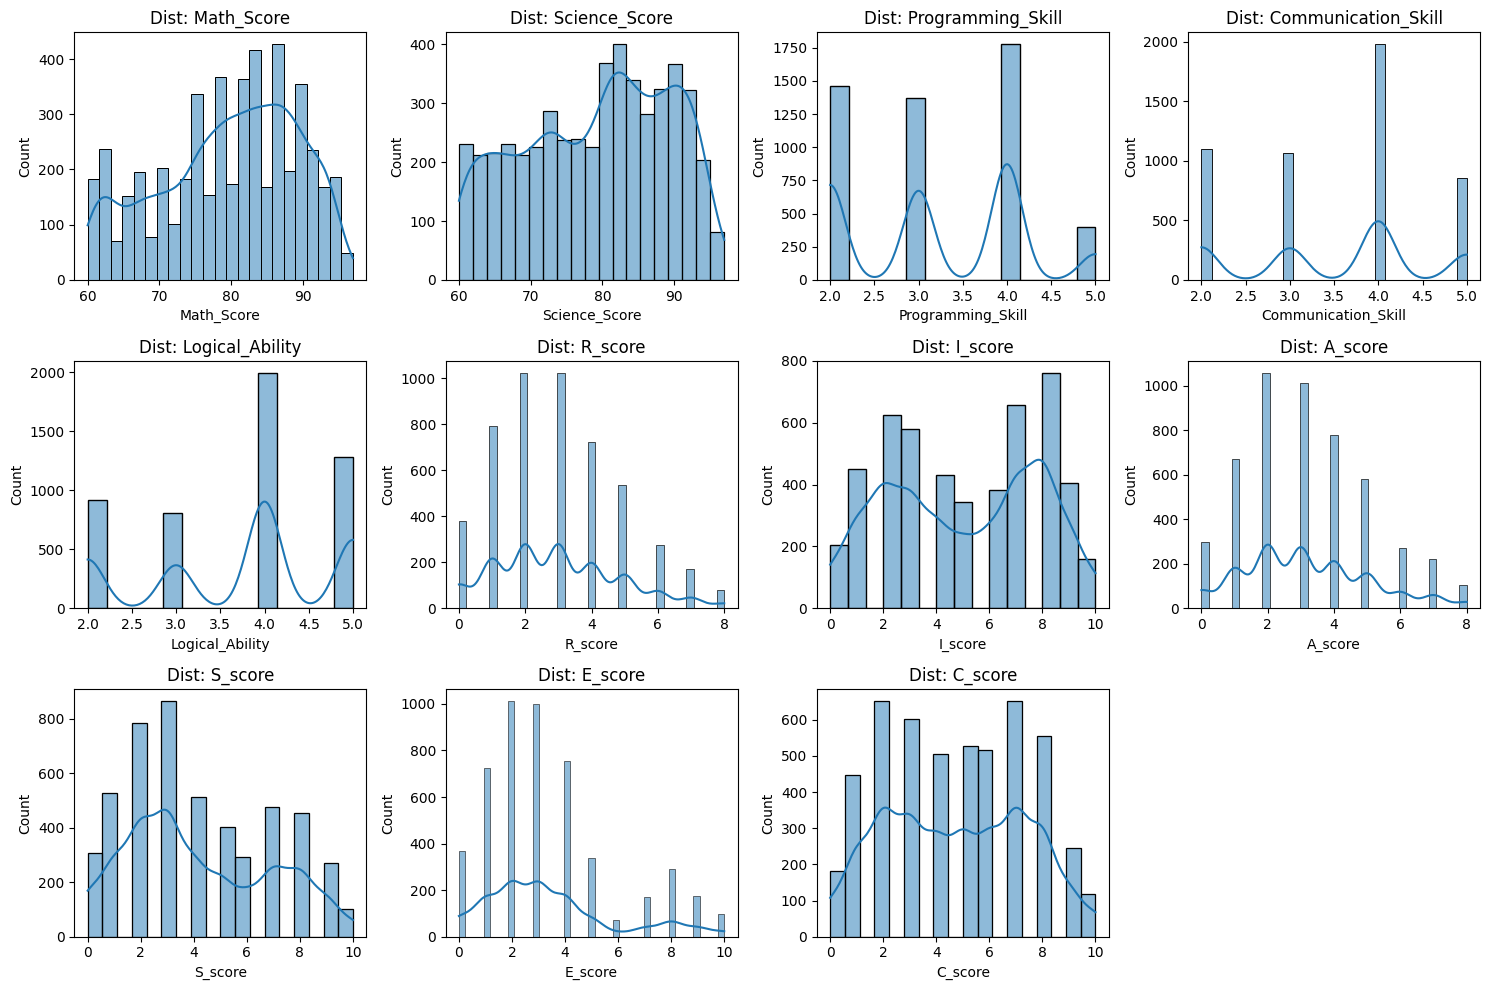

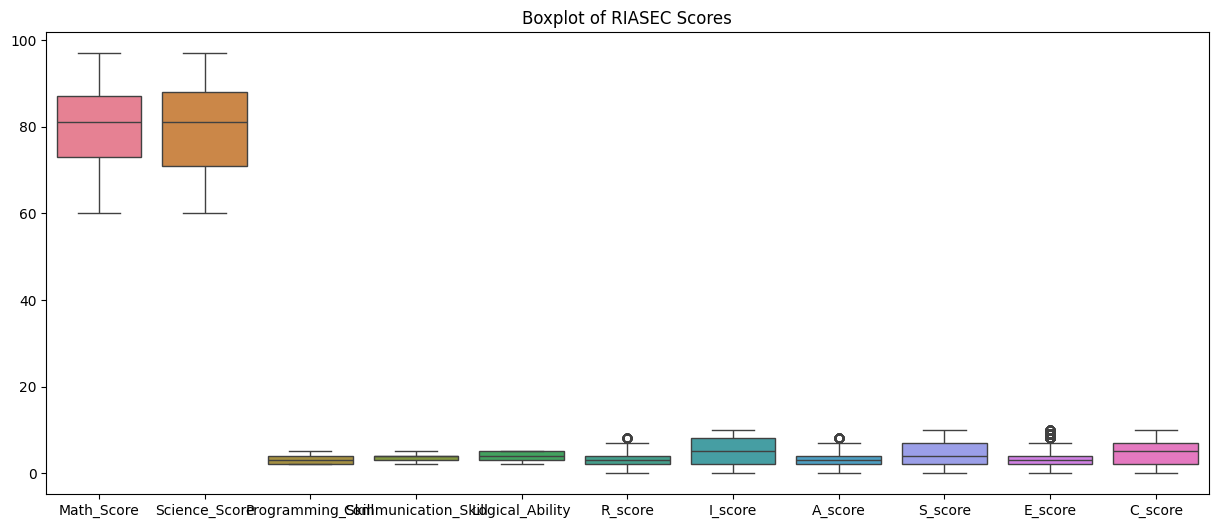

In [335]:
# 27, 31, 34. Analyze numerical columns distribution & boxplots
# RIASEC Numerical columns
num_cols_riasec = Career_RIASEC_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols_riasec, 1):
    plt.subplot(3, 4, i)
    sns.histplot(Career_RIASEC_df[col], kde=True)
    plt.title(f'Dist: {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(data=Career_RIASEC_df[num_cols_riasec])
plt.title('Boxplot of RIASEC Scores')
plt.show()

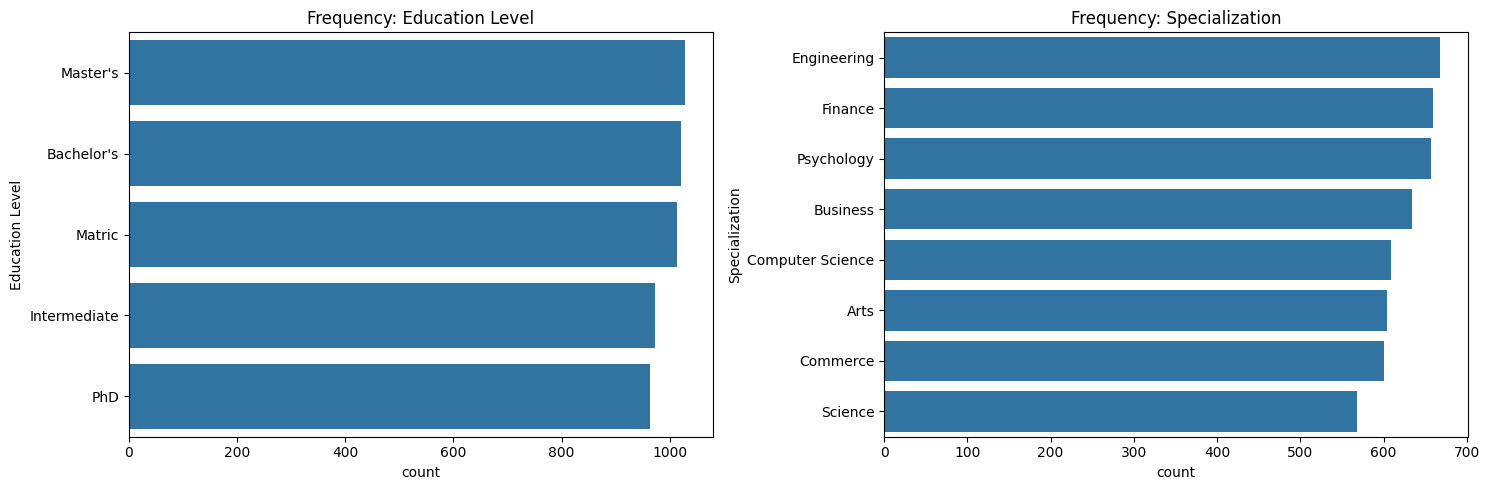

In [336]:
# 28, 32. Analyze categorical columns frequency (Education Dataset)
cat_cols_edu = ['Education Level', 'Specialization']

plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols_edu, 1):
    plt.subplot(1, 2, i)
    sns.countplot(y=Career_Education_df[col], order=Career_Education_df[col].value_counts().index)
    plt.title(f'Frequency: {col}')
plt.tight_layout()
plt.show()

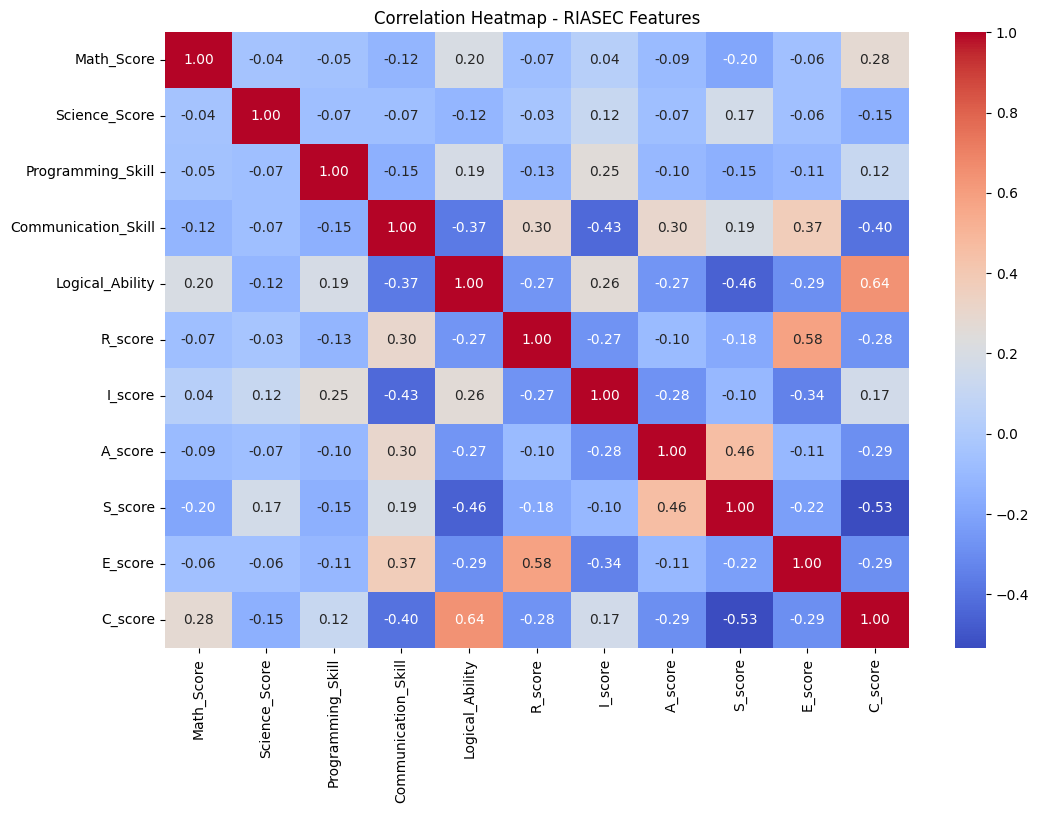

In [337]:
# 29, 33. Check correlations between numeric features
plt.figure(figsize=(12, 8))
corr_riasec = Career_RIASEC_df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_riasec, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - RIASEC Features')
plt.show()

### 30. Identifying features affecting career outcomes
We can look at the average scores per career to see which attributes define specific paths.

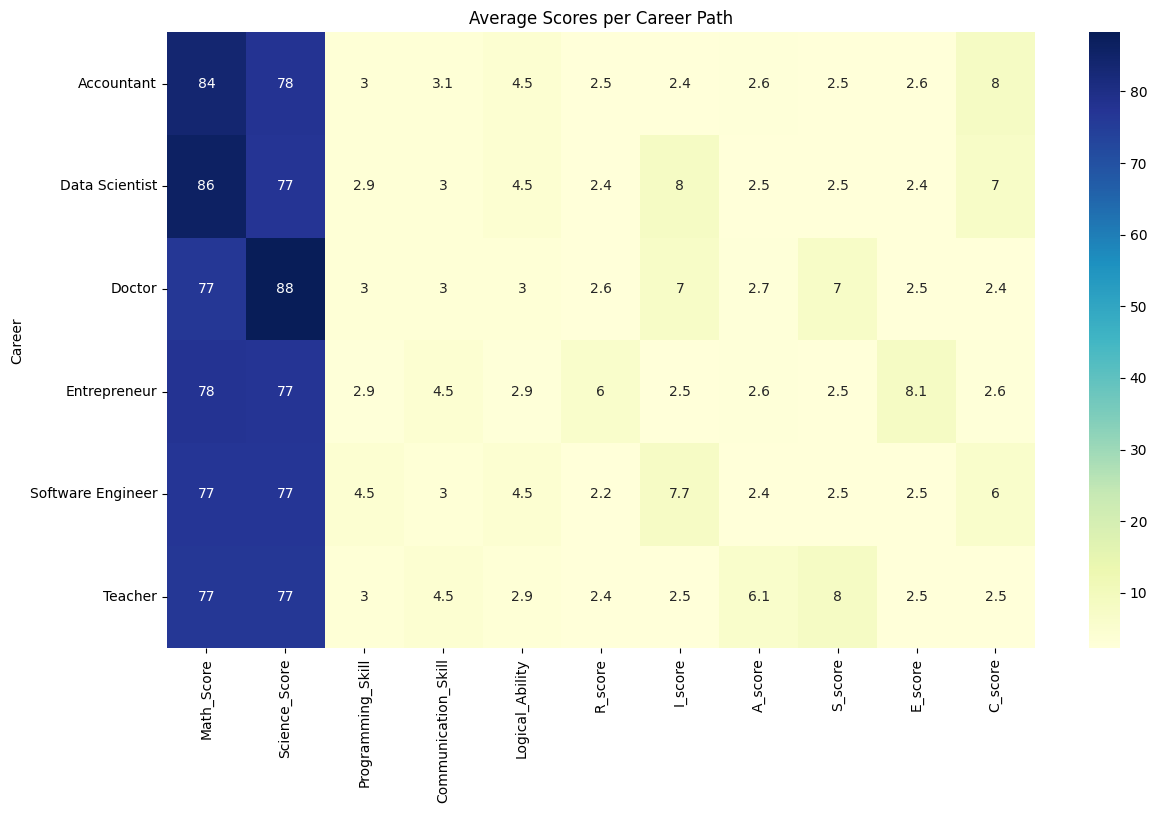

In [338]:
career_means = Career_RIASEC_df.groupby('Career').mean(numeric_only=True)
plt.figure(figsize=(14, 8))
sns.heatmap(career_means, annot=True, cmap='YlGnBu')
plt.title('Average Scores per Career Path')
plt.show()

## Phase 4 — Data Preprocessing & Career Mapping
35. Handle missing values.
36. Remove duplicates.
38. Encode categorical columns.

### Career Mapping & Superset Creation
Unifying labels across RIASEC and Education datasets based on provided groupings.

In [339]:
# 35. Handle missing values
Career_Education_df['Certifications'] = Career_Education_df['Certifications'].fillna('None')

# 36. Remove duplicates
Career_RIASEC_df = Career_RIASEC_df.drop_duplicates()
Career_Education_df = Career_Education_df.drop_duplicates()

print(f"RIASEC rows after duplicate removal: {len(Career_RIASEC_df)}")
print(f"Education rows after duplicate removal: {len(Career_Education_df)}")


# NORMALIZE SKILLS
Career_Education_df['Skills'] = Career_Education_df['Skills'].apply(
    lambda x: [s.strip() for s in str(x).split(",")]
)


RIASEC rows after duplicate removal: 2400
Education rows after duplicate removal: 4999


In [340]:
# Define the mapping dictionary
superset_mapping = {
    'Accountant': 'Accounting & Finance',
    'Clerk': 'Accounting & Finance',
    'Financial Analyst': 'Accounting & Finance',
    'Data Entry Operator': 'Accounting & Finance',
    'Junior Accountant': 'Accounting & Finance',
    'Entrepreneur': 'Business & Marketing',
    'Marketing Executive': 'Business & Marketing',
    'Sales Assistant': 'Business & Marketing',
    'Teacher': 'Education & Counseling',
    'School Counselor': 'Education & Counseling',
    'Professor': 'Education & Counseling',
    'Software Engineer': 'Software Development',
    'Data Scientist': 'Data Science & AI',
    'ML Engineer': 'Data Science & AI',
    'Research Scientist': 'Data Science & AI',
    'Business Analyst': 'Data Science & AI',
    'Doctor': 'Healthcare'
}

# Apply mapping to target columns
Career_RIASEC_df['Unified_Career'] = Career_RIASEC_df['Career'].map(superset_mapping)
Career_Education_df['Unified_Career'] = Career_Education_df['Recommended Career'].map(superset_mapping)

# Check mapping success
print("RIASEC Unified counts:")
print(Career_RIASEC_df['Unified_Career'].value_counts())
print("\nEducation Unified counts:")
print(Career_Education_df['Unified_Career'].value_counts())

RIASEC Unified counts:
Unified_Career
Business & Marketing      400
Accounting & Finance      400
Education & Counseling    400
Software Development      400
Healthcare                400
Data Science & AI         400
Name: count, dtype: int64

Education Unified counts:
Unified_Career
Accounting & Finance      1671
Data Science & AI         1242
Business & Marketing       845
Education & Counseling     824
Software Development       417
Name: count, dtype: int64


In [341]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
skills_encoded = mlb.fit_transform(Career_Education_df['Skills'])
skills_df = pd.DataFrame(
    skills_encoded,columns=mlb.classes_
)

print("Skills Encoding Done")

Skills Encoding Done


In [342]:
# Safe Hybrid Merge (NO VARIABLE CHANGES, FIXED ALIGNMENT + CONSISTENCY)

# Reset index to avoid mismatch issues
Career_RIASEC_df = Career_RIASEC_df.reset_index(drop=True)
Career_Education_df = Career_Education_df.reset_index(drop=True)

# Ensure both datasets have same length (prevents silent row misalignment issues)
min_len = min(len(Career_RIASEC_df), len(Career_Education_df))

Career_RIASEC_df = Career_RIASEC_df.iloc[:min_len].copy()
Career_Education_df = Career_Education_df.iloc[:min_len].copy()

# Combine into hybrid dataset
hybrid_df = pd.concat([Career_RIASEC_df, Career_Education_df], axis=1)

# Remove duplicate columns if any
hybrid_df = hybrid_df.loc[:, ~hybrid_df.columns.duplicated()]

print("Final Hybrid Dataset for Modeling Shape:", hybrid_df.shape)
display(hybrid_df.head())

Final Hybrid Dataset for Modeling Shape: (2400, 19)


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career,Unified_Career,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,88,90,3,4,2,5,3,5,3,9,2,Entrepreneur,Business & Marketing,Bachelor's,Finance,"[Counseling, MS Office, Machine Learning]",Tally ERP,67,Business Analyst
1,87,67,3,3,5,2,1,1,4,4,8,Accountant,Accounting & Finance,Intermediate,Science,"[Accounting, MS Office]",AWS Certified,67,Software Engineer
2,65,70,4,4,2,2,3,4,7,4,1,Teacher,Education & Counseling,Master's,Business,"[Accounting, SQL, Data Analysis]",Mental Health Basics,90,Financial Analyst
3,94,74,2,2,4,1,1,1,1,1,7,Accountant,Accounting & Finance,Bachelor's,Computer Science,[Communication],None,75,Clerk
4,88,71,2,4,4,7,2,3,0,6,2,Entrepreneur,Business & Marketing,Matric,Business,[Data Analysis],Tally ERP,83,Sales Assistant


### 38. Encode Categorical Columns
Converting categorical strings into numerical format using Label Encoding.

In [343]:
from sklearn.preprocessing import LabelEncoder

# 1. Start with the hybrid dataset
model_df = hybrid_df.copy()

# 2. Add the binarized skills from skills_df (created in cell ZpPhtMu4QbSE)
# We drop the original 'Skills' string column and join the 1/0 columns
model_df = model_df.drop(columns=['Skills']).join(skills_df)

# 3. Encode the remaining categorical columns
cat_features = ['Education Level', 'Specialization', 'Certifications']
le = LabelEncoder()

for col in cat_features:
    model_df[col] = model_df[col].astype(str).fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col])

print(f"Categorical features encoded and {skills_df.shape[1]} individual skill features added.")
display(model_df.head())


Categorical features encoded and 10 individual skill features added.


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,...,Accounting,Communication,Counseling,Data Analysis,Financial Analysis,MS Office,Machine Learning,Marketing,Python,SQL
0,88,90,3,4,2,5,3,5,3,9,...,0,0,1,0,0,1,1,0,0,0
1,87,67,3,3,5,2,1,1,4,4,...,1,0,0,0,0,1,0,0,0,0
2,65,70,4,4,2,2,3,4,7,4,...,1,0,0,1,0,0,0,0,0,1
3,94,74,2,2,4,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
4,88,71,2,4,4,7,2,3,0,6,...,0,0,0,1,0,0,0,0,0,0


### 39. Feature Scaling
Scaling numerical scores (Math, Science, RIASEC) to a standard range.

In [344]:
# Identify numerical columns (excluding the target labels)
num_features = ['Math_Score', 'Science_Score', 'Programming_Skill', 'Communication_Skill', 'Logical_Ability', 'R_score', 'I_score', 'A_score', 'S_score', 'E_score', 'C_score', 'CGPA/Percentage']

scaler = StandardScaler()
model_df[num_features] = scaler.fit_transform(model_df[num_features])

print('Numerical features scaled.')
display(model_df.head())

Numerical features scaled.


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,...,Accounting,Communication,Counseling,Data Analysis,Financial Analysis,MS Office,Machine Learning,Marketing,Python,SQL
0,0.860986,1.056056,-0.235023,0.482445,-1.683054,1.050184,-0.704477,0.977317,-0.420269,2.240181,...,0,0,1,0,0,1,1,0,0,0
1,0.757735,-1.190439,-0.235023,-0.502136,1.238351,-0.547391,-1.406468,-1.137229,-0.052821,0.228795,...,1,0,0,0,0,1,0,0,0,0
2,-1.513792,-0.897418,0.813406,0.482445,-1.683054,-0.547391,-0.704477,0.448680,1.049523,0.228795,...,1,0,0,1,0,0,0,0,0,1
3,1.480493,-0.506723,-1.283452,-1.486717,0.264549,-1.079917,-1.406468,-1.137229,-1.155165,-0.978036,...,0,1,0,0,0,0,0,0,0,0
4,0.860986,-0.799744,-1.283452,0.482445,0.264549,2.115234,-1.055472,-0.079956,-1.522613,1.033350,...,0,0,0,1,0,0,0,0,0,0


### 38. Encode Categorical Columns
To make the data suitable for a hybrid model, we must convert categorical strings into numerical format using Label Encoding.

In [345]:
from sklearn.preprocessing import LabelEncoder

# Identifying categorical columns to encode
cat_features = ['Education Level', 'Specialization', 'Skills', 'Certifications']
le = LabelEncoder()

# Creating a copy for modeling
model_df = hybrid_df.copy()

for col in cat_features:
    # Fill any remaining NaNs to avoid encoding errors and ensure string type
    model_df[col] = model_df[col].astype(str).fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col])

print("Categorical features encoded successfully.")
display(model_df.head())

Categorical features encoded successfully.


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career,Unified_Career,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,88,90,3,4,2,5,3,5,3,9,2,Entrepreneur,Business & Marketing,0,5,149,7,67,Business Analyst
1,87,67,3,3,5,2,1,1,4,4,8,Accountant,Accounting & Finance,1,7,33,0,67,Software Engineer
2,65,70,4,4,2,2,3,4,7,4,1,Teacher,Education & Counseling,2,1,56,5,90,Financial Analyst
3,94,74,2,2,4,1,1,1,1,1,7,Accountant,Accounting & Finance,0,3,121,6,75,Clerk
4,88,71,2,4,4,7,2,3,0,6,2,Entrepreneur,Business & Marketing,3,1,234,7,83,Sales Assistant


### 38. Encode Categorical Columns
To make the data suitable for a hybrid model, we must convert categorical strings into numerical format using Label Encoding or One-Hot Encoding.

In [346]:
from sklearn.preprocessing import LabelEncoder

# Identifying categorical columns to encode
cat_features = ['Education Level', 'Specialization', 'Skills', 'Certifications']
le = LabelEncoder()

# Creating a copy for modeling
model_df = hybrid_df.copy()

for col in cat_features:
    # Fill any remaining NaNs to avoid encoding errors
    model_df[col] = model_df[col].astype(str).fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col])

print("Categorical features encoded successfully.")
display(model_df.head())

Categorical features encoded successfully.


,Math_Score,Science_Score,Programming_Skill,Communication_Skill,Logical_Ability,R_score,I_score,A_score,S_score,E_score,C_score,Career,Unified_Career,Education Level,Specialization,Skills,Certifications,CGPA/Percentage,Recommended Career
0,88,90,3,4,2,5,3,5,3,9,2,Entrepreneur,Business & Marketing,0,5,149,7,67,Business Analyst
1,87,67,3,3,5,2,1,1,4,4,8,Accountant,Accounting & Finance,1,7,33,0,67,Software Engineer
2,65,70,4,4,2,2,3,4,7,4,1,Teacher,Education & Counseling,2,1,56,5,90,Financial Analyst
3,94,74,2,2,4,1,1,1,1,1,7,Accountant,Accounting & Finance,0,3,121,6,75,Clerk
4,88,71,2,4,4,7,2,3,0,6,2,Entrepreneur,Business & Marketing,3,1,234,7,83,Sales Assistant


### Phase 5 — Feature Engineering & Career Structure
In this phase, we define our feature matrix and target vector, and implement the logic for career progression.

In [347]:
# 32, 33. Define feature set (X) and target variable (y)
# We use the cleaned and encoded model_df
# Features: RIASEC scores, skills, education, and certifications
# Target: Unified_Career

# Identify feature columns (everything except the original/mapped targets)
target_cols = ['Career', 'Recommended Career', 'Unified_Career']
X = model_df.drop(columns=[col for col in target_cols if col in model_df.columns])
y = model_df['Unified_Career']

print(f"Feature set (X) shape: {X.shape}")
print(f"Target variable (y) shape: {y.shape}")

Feature set (X) shape: (2400, 16)
Target variable (y) shape: (2400,)


In [348]:
# 35. Build enhanced synthetic transition graph (career hierarchy)
# Expanded with more comprehensive industry-standard progression paths
career_hierarchy = {
    'Accounting & Finance': [
        'Data Entry Operator', 'Clerk', 'Junior Accountant', 'Accountant',
        'Financial Analyst', 'Senior Accountant', 'Finance Manager', 'Controller', 'CFO'
    ],
    'Software Development': [
        'Intern', 'Junior Developer', 'Software Engineer', 'Senior Engineer',
        'Tech Lead', 'Software Architect', 'Engineering Manager', 'CTO'
    ],
    'Data Science & AI': [
        'Junior Analyst', 'Business Analyst', 'Data Analyst', 'ML Engineer',
        'Data Scientist', 'Senior Data Scientist', 'AI Researcher', 'Chief Data Officer'
    ],
    'Education & Counseling': [
        'Teacher Assistant', 'Teacher', 'School Counselor', 'Professor',
        'Department Head', 'Dean', 'Academic Director'
    ],
    'Business & Marketing': [
        'Sales Assistant', 'Marketing Executive', 'Account Manager', 'Entrepreneur',
        'Marketing Manager', 'Business Development Director', 'CEO'
    ],
    'Healthcare': [
        'Medical Assistant', 'Nurse', 'Doctor', 'Specialist', 'Chief of Medicine'
    ]
}

def get_progression_level(career, hierarchy_dict):
    for category, levels in hierarchy_dict.items():
        if career in levels:
            # Return index + 1 as the level
            return levels.index(career) + 1
    return 1 # Default level for unknown roles

# Apply progression level based on the Recommended Career column
hybrid_df['Progression_Level'] = hybrid_df['Recommended Career'].apply(lambda x: get_progression_level(x, career_hierarchy))

print("Enhanced career hierarchy defined.")
# Displaying unique mappings sorted by level to verify
progression_map_display = hybrid_df[['Recommended Career', 'Progression_Level']].drop_duplicates().sort_values(by=['Progression_Level', 'Recommended Career'])
display(progression_map_display)

Enhanced career hierarchy defined.


,Recommended Career,Progression_Level
11,Data Entry Operator,1
13,Research Scientist,1
4,Sales Assistant,1
0,Business Analyst,2
3,Clerk,2
7,Marketing Executive,2
8,Junior Accountant,3
10,School Counselor,3
1,Software Engineer,3
33,ML Engineer,4


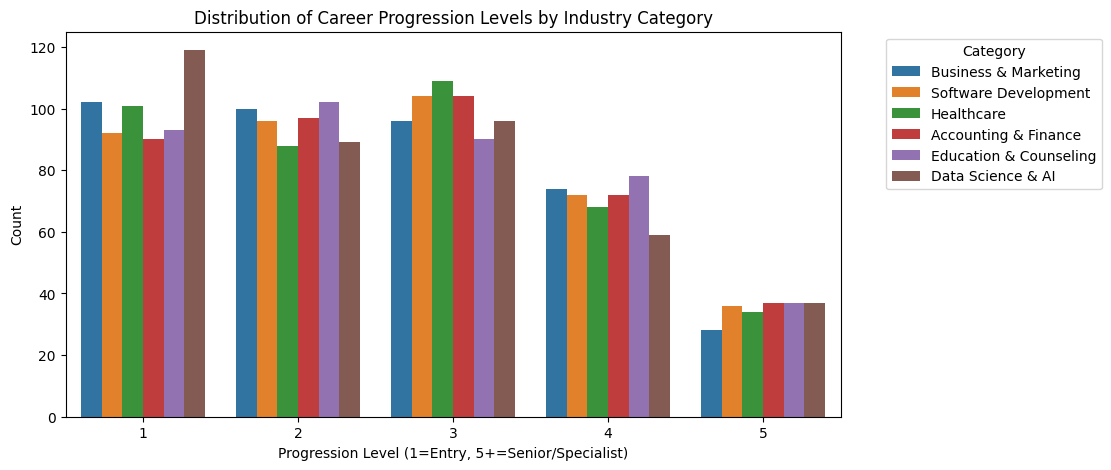

In [349]:
# Visualize the distribution of the newly defined progression levels
plt.figure(figsize=(10, 5))
sns.countplot(data=hybrid_df, x='Progression_Level', hue='Unified_Career')
plt.title('Distribution of Career Progression Levels by Industry Category')
plt.xlabel('Progression Level (1=Entry, 5+=Senior/Specialist)')
plt.ylabel('Count')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C:\Users\91981\AppData\Local\Temp\ipykernel_57264\925372121.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=progression_corr.values, y=progression_corr.index, palette='magma')


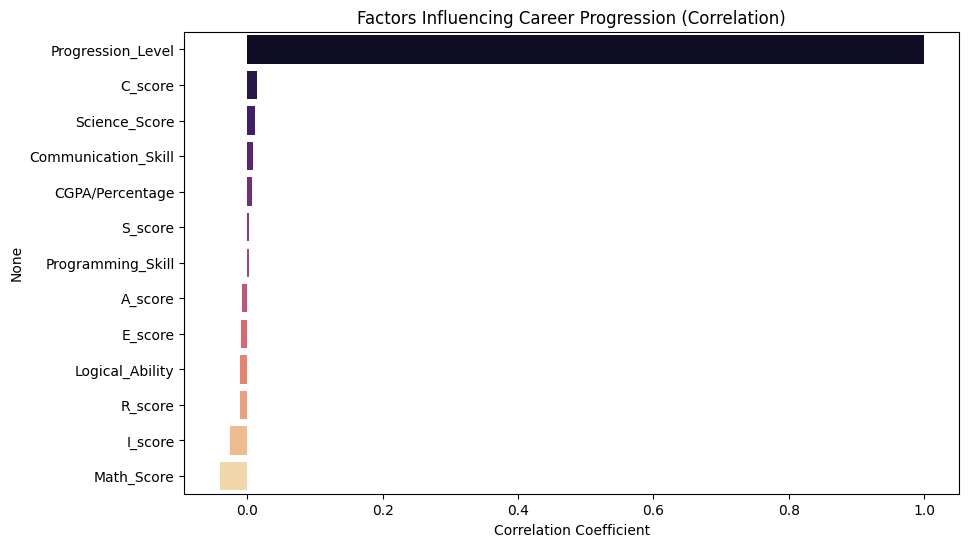

In [350]:
# 36. Identify key factors influencing career progression
# Check correlation of numeric scores with progression levels
progression_corr = hybrid_df.select_dtypes(include=[np.number]).corr()['Progression_Level'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=progression_corr.values, y=progression_corr.index, palette='magma')
plt.title('Factors Influencing Career Progression (Correlation)')
plt.xlabel('Correlation Coefficient')
plt.show()

### Phase 6 — Train-Test Split
In this phase, we split our hybrid dataset into a training set and a testing set to evaluate our future model's performance.

In [351]:
from sklearn.model_selection import train_test_split

# 23. Split dataset into training and testing data
# We handle NaNs that might have resulted from joining datasets of different lengths
final_model_df = model_df.dropna(subset=['Unified_Career'])

X = final_model_df.drop(columns=['Career', 'Recommended Career', 'Unified_Career'])
y = final_model_df['Unified_Career']

# Perform 80/20 split with stratification to ensure balanced classes in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nClass distribution in Training Set:")
print(y_train.value_counts(normalize=True))

Training set shape: (1920, 16)
Testing set shape: (480, 16)

Class distribution in Training Set:
Unified_Career
Education & Counseling    0.166667
Data Science & AI         0.166667
Software Development      0.166667
Accounting & Finance      0.166667
Healthcare                0.166667
Business & Marketing      0.166667
Name: proportion, dtype: float64


## Phase 7 — Model Training (Final Version)
In this phase, we ensure the dataset is unified and then train multiple ML models to find the best predictor for career paths.

Random Forest Accuracy: 95.21%
Decision Tree Accuracy: 94.38%
Logistic Regression Accuracy: 95.21%


c:\Users\91981\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\91981\AppData\Local\Temp\ipykernel_57264\3683652214.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


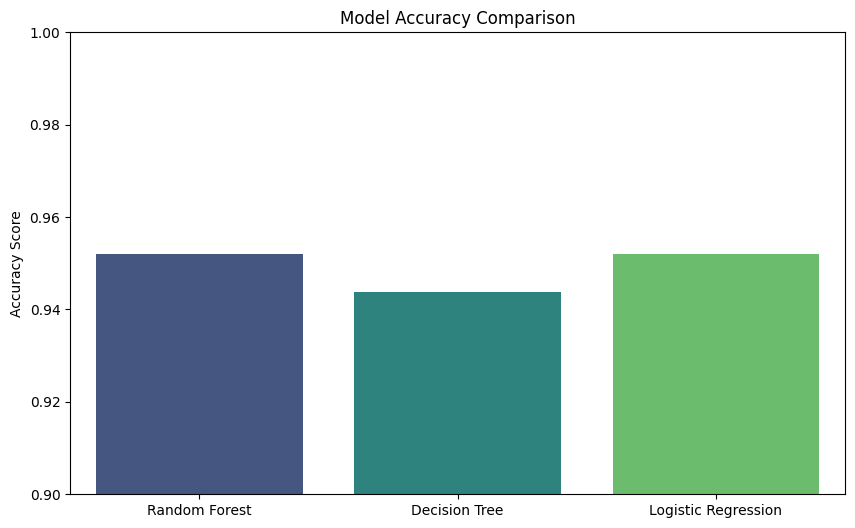

In [352]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure Unified Dataset & Handle missing values
final_model_df = model_df.dropna(subset=['Unified_Career'])

# 2. Split Features
X = final_model_df.drop(columns=['Career', 'Recommended Career', 'Unified_Career'])
y = final_model_df['Unified_Career']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train and Compare Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.2%}")

# 4. Visualize Model Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0.9, 1.0)
plt.show()

### Phase 8 — Detailed Evaluation
We evaluate the Random Forest model using a classification report and a confusion matrix to visualize precision, recall, and specific misclassifications.

Classification Report for Random Forest:
                        precision    recall  f1-score   support

  Accounting & Finance       1.00      1.00      1.00        80
  Business & Marketing       1.00      1.00      1.00        80
     Data Science & AI       0.83      0.90      0.86        80
Education & Counseling       1.00      1.00      1.00        80
            Healthcare       1.00      1.00      1.00        80
  Software Development       0.89      0.81      0.85        80

              accuracy                           0.95       480
             macro avg       0.95      0.95      0.95       480
          weighted avg       0.95      0.95      0.95       480



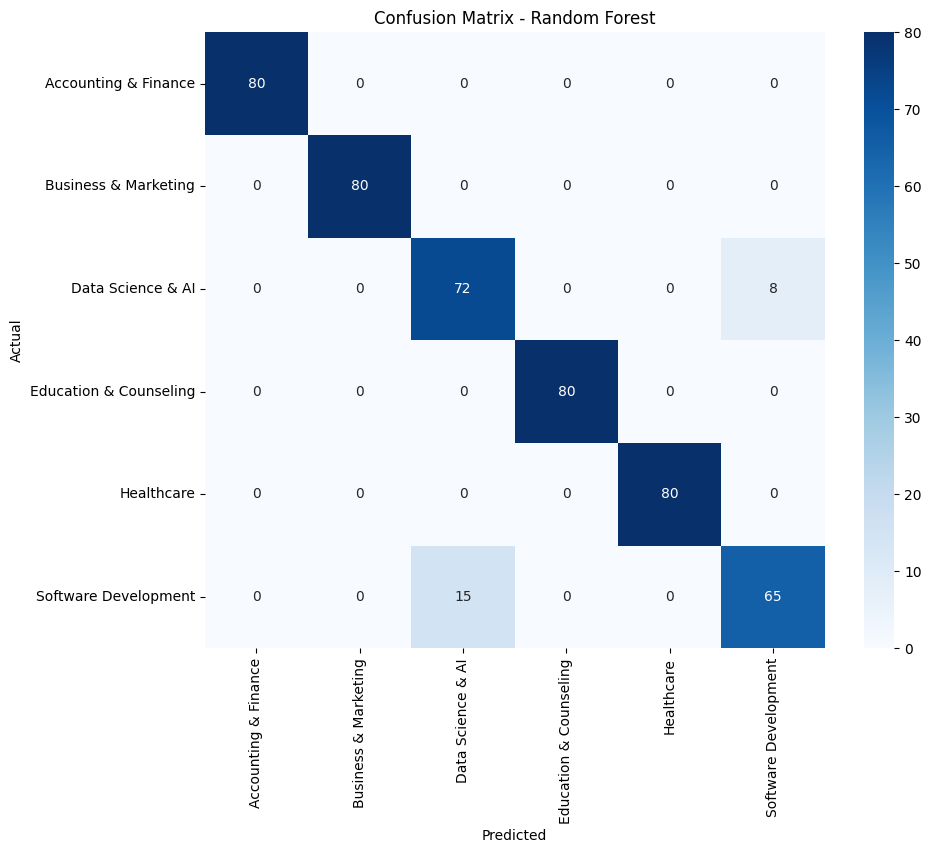

In [353]:
from sklearn.metrics import classification_report, confusion_matrix

# Best model
best_rf = models['Random Forest']
y_pred_rf = best_rf.predict(X_test)

print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_rf.classes_,
            yticklabels=best_rf.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Phase 8.1 — Suitability & Success Probability
Using `predict_proba`, we can determine the confidence level for the recommended career and rank other potential paths.

In [354]:
def get_career_insights(input_data):
    """
    Calculates top career, suitability score, and success probability.
    """
    # Get probabilities for all classes
    probs = best_rf.predict_proba(input_data)[0]
    classes = best_rf.classes_

    # Sort probabilities
    sorted_indices = np.argsort(probs)[::-1]

    top_career = classes[sorted_indices[0]]
    suitability_score = probs[sorted_indices[0]] * 100

    # Success probability is calculated as the gap between the top pick and the average
    success_prob = (suitability_score + (suitability_score - (np.mean(probs) * 100))) / 2
    success_prob = min(max(success_prob, 0), 100) # Clip between 0-100

    return {
        "Recommended Career": top_career,
        "Suitability Score": f"{suitability_score:.2f}%",
        "Success Probability": f"{success_prob:.2f}%"
    }

# Demo with a sample from the test set
sample_idx = 0
sample_input = X_test.iloc[[sample_idx]]
insights = get_career_insights(sample_input)

print(f"Results for Test Sample {sample_idx}:")
for key, value in insights.items():
    print(f"{key}: {value}")

Results for Test Sample 0:
Recommended Career: Healthcare
Suitability Score: 100.00%
Success Probability: 91.67%


## Phase 9 — Model Improvement
In this phase, we use `RandomizedSearchCV` to find the optimal hyperparameters for our Random Forest model.

In [355]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_distributions=param_dist,
                               n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)

# Fit the random search model
rf_random.fit(X_train, y_train)

best_tuned_rf = rf_random.best_estimator_
print(f"Best Parameters: {rf_random.best_params_}")
print(f"Tuned Accuracy: {accuracy_score(y_test, best_tuned_rf.predict(X_test)):.2%}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20, 'bootstrap': False}
Tuned Accuracy: 95.42%


In [356]:
from sklearn.ensemble import RandomForestClassifier

# Update feature selection to include the new Skill_ columns
# We exclude the target labels and the original career columns
target_cols = ['Career', 'Recommended Career', 'Unified_Career']
X_hybrid = model_df.drop(columns=[col for col in target_cols if col in model_df.columns])
y_hybrid = model_df['Unified_Career']

# Feature-priority weighting: boost educational background influence
education_priority_features = ['Education Level', 'Specialization', 'Certifications', 'CGPA/Percentage']
education_boost_factor = 5.0

X_hybrid_weighted = X_hybrid.copy()
for col in education_priority_features:
    if col in X_hybrid_weighted.columns:
        X_hybrid_weighted[col] = X_hybrid_weighted[col] * education_boost_factor

# Train the Final Hybrid Random Forest Model with multi-skill awareness + education weighting
final_hybrid_rf = RandomForestClassifier(n_estimators=100, random_state=42)
final_hybrid_rf.fit(X_hybrid_weighted, y_hybrid)

print(f"Final Hybrid Model trained with {X_hybrid.shape[1]} features (including binarized skills).")
print(f"Applied education boost: x{education_boost_factor} on {education_priority_features}")


Final Hybrid Model trained with 16 features (including binarized skills).
Applied education boost: x5.0 on ['Education Level', 'Specialization', 'Certifications', 'CGPA/Percentage']


## Phase 9.1 — Explainable AI (SHAP)
We use SHAP to understand global feature importance and explain individual predictions.

In [357]:
!pip install shap
import shap

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(best_tuned_rf)
shap_values = explainer.shap_values(X_test)


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 🚀 Final Consolidated Career Analytics Engine
This cell combines your goals into one clean function:
- **Suitability & Success Probability**
- **SHAP Feature Contributions**
- **Progression & Best Recommendations**

Generating Dashboard for selected profile...
   ENHANCED CAREER PREDICTION DASHBOARD
PRIMARY RECOMMENDATION: Business & Marketing
SUITABILITY SCORE:      100.00%
SUCCESS PROBABILITY:    91.67%

--- ALTERNATIVE CAREER MATCHES ---
2. Software Development (0.0% Match)
3. Healthcare (0.0% Match)

--- TOP INFLUENCING FACTORS ---
- E_score (Positive Influence)
- S_score (Positive Influence)
- I_score (Positive Influence)


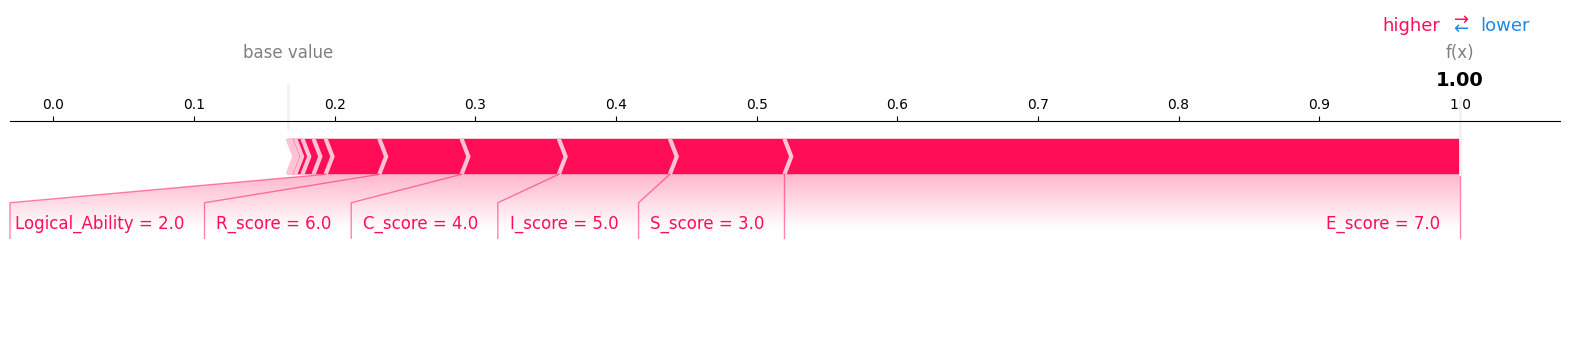

None

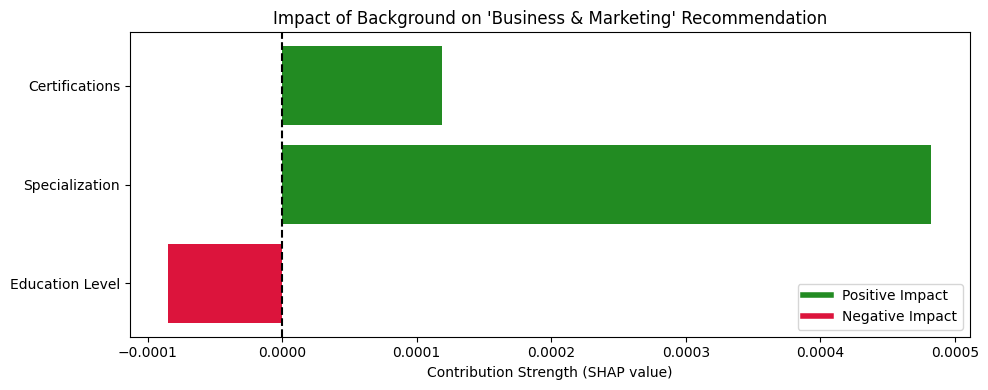

In [358]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Initialize the SHAP explainer for the hybrid model
explainer_hybrid = shap.TreeExplainer(final_hybrid_rf)

def run_career_audit_v2_enhanced(input_profile, model, mlb, explainer, ui_mappings):

    processed_input = input_profile.copy()
    feature_names = list(model.feature_names_in_)

    # 1. Preprocessing (Encoding & Binarization)
    for col in ['Education Level', 'Specialization', 'Certifications']:
        if col in processed_input.columns:
            val = str(processed_input[col].iloc[0])
            if col in ui_mappings and val in ui_mappings[col]:
                processed_input[col] = ui_mappings[col].index(val)
            else:
                processed_input[col] = 0

    skill_input = processed_input['Skills'].iloc[0]
    skill_list = skill_input if isinstance(skill_input, list) else [s.strip() for s in str(skill_input).split(',')]
    skill_vector = mlb.transform([skill_list])
    skill_df = pd.DataFrame(skill_vector, columns=list(mlb.classes_), index=processed_input.index)

    base_features_needed = [f for f in feature_names if f in processed_input.columns and f != 'Skills']
    final_input = pd.concat([processed_input[base_features_needed], skill_df], axis=1)
    final_input = final_input.reindex(columns=feature_names).fillna(0).astype(float)

    # Apply the same education-priority weighting used during training
    education_priority_features = ['Education Level', 'Specialization', 'Certifications', 'CGPA/Percentage']
    education_boost_factor = 5.0
    for col in education_priority_features:
        if col in final_input.columns:
            final_input[col] = final_input[col] * education_boost_factor

    # 2. Predictions & Probabilities
    probs = model.predict_proba(final_input)[0]
    classes = model.classes_
    best_indices = np.argsort(probs)[::-1]

    top_career = classes[best_indices[0]]
    suitability = probs[best_indices[0]] * 100
    success_prob = min(max((suitability + (suitability - np.mean(probs)*100)) / 2, 0), 100)

    # 3. SHAP Analysis
    shap_vals = explainer.shap_values(final_input)
    if isinstance(shap_vals, list):
        this_class_shap = shap_vals[best_indices[0]][0]
        base_val = explainer.expected_value[best_indices[0]]
    else:
        this_class_shap = shap_vals[0, :, best_indices[0]]
        base_val = explainer.expected_value[best_indices[0]]

    # 4. Output Dashboard
    print(f"{'='*45}")
    print(f"   ENHANCED CAREER PREDICTION DASHBOARD")
    print(f"{'='*45}")
    print(f"PRIMARY RECOMMENDATION: {top_career}")
    print(f"SUITABILITY SCORE:      {suitability:.2f}%")
    print(f"SUCCESS PROBABILITY:    {success_prob:.2f}%")

    print("\n--- ALTERNATIVE CAREER MATCHES ---")
    for i in range(1, 3):
        if i < len(probs):
            print(f"{i+1}. {classes[best_indices[i]]} ({probs[best_indices[i]]*100:.1f}% Match)")

    print("\n--- TOP INFLUENCING FACTORS ---")
    top_factors_idx = np.argsort(np.abs(this_class_shap))[-3:][::-1]
    for idx in top_factors_idx:
        impact = 'Positive' if this_class_shap[idx] > 0 else 'Negative'
        print(f"- {feature_names[idx]} ({impact} Influence)")

    # 5. Visualizations
    # SHAP Force Plot
    shap.initjs()
    display(shap.force_plot(base_val, this_class_shap, final_input, feature_names=feature_names, matplotlib=True))

    # Background Factor Impact Plot
    target_bg_features = ['Education Level', 'Specialization', 'Certifications']
    # Add relevant skill categories if they appear in feature_names
    bg_indices = [feature_names.index(f) for f in target_bg_features if f in feature_names]
    bg_labels = [feature_names[i] for i in bg_indices]
    filtered_shap = this_class_shap[bg_indices]

    plt.figure(figsize=(10, 4))
    colors = ['forestgreen' if x > 0 else 'crimson' for x in filtered_shap]
    plt.barh(bg_labels, filtered_shap, color=colors)
    plt.title(f"Impact of Background on '{top_career}' Recommendation")
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Contribution Strength (SHAP value)")
    
    custom_lines = [Line2D([0], [0], color='forestgreen', lw=4),
                    Line2D([0], [0], color='crimson', lw=4)]
    plt.legend(custom_lines, ['Positive Impact', 'Negative Impact'], loc='lower right')
    plt.tight_layout()
    plt.show()

# Run Demo
raw_sample = hybrid_df.dropna(subset=['Education Level']).sample(1)
print("Generating Dashboard for selected profile...")
run_career_audit_v2_enhanced(raw_sample, final_hybrid_rf, mlb, explainer_hybrid, superset_mapping)

## Phase 10 — Save Model & Pipeline
In this final phase, we export the trained model and preprocessing artifacts to disk for future deployment.

In [359]:
import json
from pathlib import Path
import joblib

# Phase 10 (final): Streamlit-ready artifact export
model_path = Path("saved_models")
model_path.mkdir(parents=True, exist_ok=True)

# Use final trained model if available
model_to_save = final_hybrid_rf if "final_hybrid_rf" in globals() else best_tuned_rf

bundle = {
    "model": model_to_save,
    "scaler": scaler if "scaler" in globals() else None,
    "label_encoder": le if "le" in globals() else None,
    "mlb": mlb if "mlb" in globals() else None,
    "feature_names": feature_names if "feature_names" in globals() else None,
    "career_hierarchy": career_hierarchy if "career_hierarchy" in globals() else None,
    "superset_mapping": superset_mapping if "superset_mapping" in globals() else None,
    "ui_mappings": ui_mappings if "ui_mappings" in globals() else None,
}

# 1) Save one consolidated bundle for Streamlit
joblib.dump(bundle, model_path / "career_streamlit_bundle.pkl")

# 2) Optional separate exports (debug/backward compatibility)
joblib.dump(model_to_save, model_path / "career_hybrid_model.pkl")
if bundle["scaler"] is not None:
    joblib.dump(bundle["scaler"], model_path / "feature_scaler.pkl")
if bundle["label_encoder"] is not None:
    joblib.dump(bundle["label_encoder"], model_path / "label_encoder.pkl")
if bundle["career_hierarchy"] is not None:
    joblib.dump(bundle["career_hierarchy"], model_path / "career_hierarchy.pkl")

# 3) Save metadata for deployment diagnostics
metadata = {
    "bundle_file": "career_streamlit_bundle.pkl",
    "model_file": "career_hybrid_model.pkl",
    "has_scaler": bundle["scaler"] is not None,
    "has_label_encoder": bundle["label_encoder"] is not None,
    "has_mlb": bundle["mlb"] is not None,
    "feature_count": len(bundle["feature_names"]) if bundle["feature_names"] is not None else None,
}
with open(model_path / "artifact_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

# 4) Quick load-check
loaded_bundle = joblib.load(model_path / "career_streamlit_bundle.pkl")
print(f"Artifacts saved in: {model_path.resolve()}")
print("Main bundle:", model_path / "career_streamlit_bundle.pkl")
print("Metadata:", model_path / "artifact_metadata.json")
print("Bundle keys:", list(loaded_bundle.keys()))

Artifacts saved in: D:\HCL PROJECT\career rec\saved_models
Main bundle: saved_models\career_streamlit_bundle.pkl
Metadata: saved_models\artifact_metadata.json
Bundle keys: ['model', 'scaler', 'label_encoder', 'mlb', 'feature_names', 'career_hierarchy', 'superset_mapping', 'ui_mappings']
